In [1]:
# Chem 277B: Machine Learning Algorithms for
#            Molecular Sciences
#
# Date Created: 11/28/2024
# Last revisited: 11/29/2024


##################################
# FILE FOR RUNNING LSTM MODEL
##################################

'''can use lstm class to tune model parameters
and compare model output to actual data. Different metrics/graphs
and visualizations can be called from the utils file'''






'can use lstm class to tune model parameters\nand compare model output to actual data. Different metrics/graphs\nand visualizations can be called from the utils file'

In [1]:
# imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nrsim_lstm import NRSIM_LSTM as lstm
import utils277b as utils
from scope_2 import NuclearReactorSimulator

2024-12-03 00:21:11.140231: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# read data from csv file

#filepath="test_file"
#data = pd.read_csv(filepath)
simulation = NuclearReactorSimulator()
simulation.run_simulation()
data = pd.DataFrame(simulation.normalize_values())
data = data.drop("Time", axis=1)

data.head(5)

,pH,Hydrogen,Total Gas,Temperature,Pressure,Radioactivity,Power,Reactor Safety,Injection of Air,Resin Overheat,Fuel Element Failure,Chemical Addition,Vent Gas
0,0.681215,0.957945,0.674956,0.218750,0.464833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.679781,0.960101,0.676954,0.230198,0.489160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.678347,0.962256,0.678951,0.241616,0.513421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.676913,0.964403,0.680942,0.252970,0.537548,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.675479,0.966538,0.682921,0.264231,0.561477,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#n_past = int(data.shape[0] * 0.5)
#m_future = data.shape[0] - n_past
n_past = 200
m_future = 200 
display(n_past)
display(m_future)

200

200

In [4]:
data

,pH,Hydrogen,Total Gas,Temperature,Pressure,Radioactivity,Power,Reactor Safety,Injection of Air,Resin Overheat,Fuel Element Failure,Chemical Addition,Vent Gas
0,0.681215,0.957945,0.674956,0.218750,0.464833,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.679781,0.960101,0.676954,0.230198,0.489160,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.678347,0.962256,0.678951,0.241616,0.513421,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.676913,0.964403,0.680942,0.252970,0.537548,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.675479,0.966538,0.682921,0.264231,0.561477,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4316,0.450787,0.606552,0.601127,0.173269,0.152014,0.953355,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4317,0.456762,0.600701,0.596885,0.184530,0.154733,0.953515,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4318,0.462737,0.594851,0.592643,0.195884,0.157451,0.953675,0.0,0.0,1.0,1.0,1.0,0.0,0.0
4319,0.468712,0.589001,0.588400,0.207302,0.160169,0.953834,0.0,0.0,1.0,1.0,1.0,0.0,0.0


In [5]:
features = 13
X, y = utils.prep_lstm_data(np.array(data), n_past, m_future)

In [6]:
X = X.squeeze()
y = y.squeeze()
X = X[:, :, :7]
y_classification = y[:, :, 7:]
y = y[:, :, :7]

In [7]:
print(X.shape, y.shape)

(3922, 200, 7) (3922, 200, 7)


In [8]:
# # setting up training data

# n_past = 100
# m_future = 50
# features = 1

# target_param = "Injection of Air"

# # t represents time steps
# t = data["Time"].values
# t = t.reshape(len(t), 1)

# # y(t) is the value of the target parameter at time t
# y_t = data[target_param].values
# y_t = y_t.reshape(len(y_t), 1)

# scaler, y_t_normalized = utils.scale(y_t)

# # creating training and testing data
# X, y = utils.prep_lstm_data(y_t_normalized, n_past, m_future)

# split_point = int(0.8 * len(data))
# X = np.array(data.iloc[:split_point, :])
# Y = np.array(data.iloc[:split_point, :])


#plt.plot(range(0, y.shape[0]), y)
#plt.xlabel("Time")
#plt.ylabel(f"{target_param}")
#plt.title(f"Nuclear Reactor Simulation {target_param} vs Time")
#plt.show()

In [9]:
# each shape[1] value corresponds to the number of points in the past 
# and number of points in the future for X and y, respectively

print(X.shape, y.shape)

(3922, 200, 7) (3922, 200, 7)


In [16]:
# train test splitting data

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

In [20]:
# model setup 

# stacked lstm layers
neurons = [32, 16]
activation = "tanh"

# temporal params
n_past_timesteps = X.shape[1]
n_features = X.shape[2]
n_predicted_timesteps = y.shape[1]

# optimization + metrics
optimizer = "adam"
loss = "mse"
metrics =["mae", "mse"]

# convolutional layer
conv_layer = False
nfilters = 64  
conv_act = 'relu' 
pool_size = 2  
dropout=0.2


my_model = lstm(
    neurons,
    activation,
    n_past_timesteps,
    n_features,
    n_predicted_timesteps,
    optimizer,
    loss,
    metrics,
    dropout,
    conv_layer,
    nfilters,
    conv_act,
    pool_size
)

2024-12-03 00:49:26.276727: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 00:49:26.278927: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 00:49:26.280579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [21]:
my_model.model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 200, 32)           5120      
                                                                 
 dropout_2 (Dropout)         (None, 200, 32)           0         
                                                                 
 lstm_5 (LSTM)               (None, 200, 16)           3136      
                                                                 
 dropout_3 (Dropout)         (None, 200, 16)           0         
                                                                 
 dense_2 (Dense)             (None, 200, 7)            119       
                                                                 
Total params: 8,375
Trainable params: 8,375
Non-trainable params: 0
_________________________________________________________________


In [22]:
# fitting model on training data

n_epochs = 20
batch_size = 32


my_model.fit(X_train, y_train, nEpochs=n_epochs, nBatches=batch_size, val_split=0.2, verb=2, shuf=False)


Epoch 1/20


2024-12-03 00:49:41.528750: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 00:49:41.531770: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 00:49:41.533888: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

74/74 - 53s - loss: 0.1003 - mae: 0.2354 - mse: 0.1003 - val_loss: 0.0479 - val_mae: 0.1458 - val_mse: 0.0479 - 53s/epoch - 712ms/step
Epoch 2/20
74/74 - 48s - loss: 0.0508 - mae: 0.1710 - mse: 0.0508 - val_loss: 0.0443 - val_mae: 0.1361 - val_mse: 0.0443 - 48s/epoch - 644ms/step
Epoch 3/20
74/74 - 46s - loss: 0.0425 - mae: 0.1548 - mse: 0.0425 - val_loss: 0.0352 - val_mae: 0.1224 - val_mse: 0.0352 - 46s/epoch - 626ms/step
Epoch 4/20
74/74 - 49s - loss: 0.0359 - mae: 0.1413 - mse: 0.0359 - val_loss: 0.0269 - val_mae: 0.1066 - val_mse: 0.0269 - 49s/epoch - 666ms/step
Epoch 5/20
74/74 - 48s - loss: 0.0329 - mae: 0.1334 - mse: 0.0329 - val_loss: 0.0292 - val_mae: 0.1122 - val_mse: 0.0292 - 48s/epoch - 649ms/step
Epoch 6/20
74/74 - 50s - loss: 0.0295 - mae: 0.1254 - mse: 0.0295 - val_loss: 0.0206 - val_mae: 0.0939 - val_mse: 0.0206 - 50s/epoch - 676ms/step
Epoch 7/20
74/74 - 51s - loss: 0.0270 - mae: 0.1187 - mse: 0.0270 - val_loss: 0.0202 - val_mae: 0.0933 - val_mse: 0.0202 - 51s/epoch - 

In [23]:
# model history

out = my_model.get_model().history

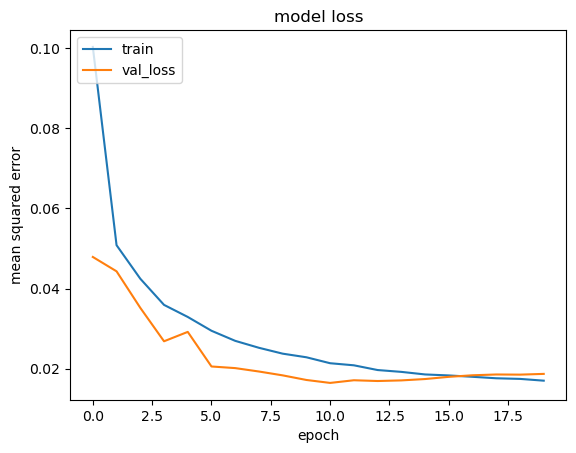

In [24]:
# plotting loss during training
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('mean squared error')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()


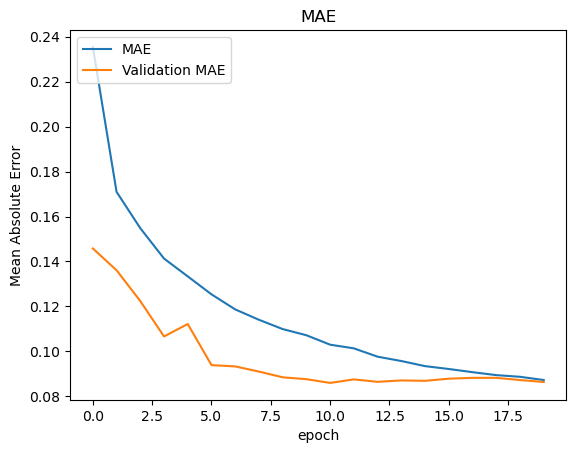

In [25]:
# plot metrics
plt.plot(out.history['mae'])
plt.plot(out.history['val_mae'])
plt.title('MAE')
plt.ylabel('Mean Absolute Error')
plt.xlabel('epoch')
plt.legend(['MAE', 'Validation MAE'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()

In [26]:
y_train.shape

(2941, 200, 7)

In [41]:
def graph_features(data, safety_features = ["Reactor Safety", "Injection of Air", "Resin Overheat", "Fuel Element Failure"]):
    colors = plt.rcParams["axes.prop_cycle"]()
    df = data
    fig, axs = plt.subplots(len(safety_features), figsize=(10,8))
    fig.suptitle('Simulated Reactor Safety Over Time')
    for i in range(len(safety_features)): 
        c = next(colors)["color"]
        x = safety_features[i]
        axs[i].plot(range(0, df.shape[0]), df[:,i], color = c)
        axs[i].set_title(x)
        axs[i].set_xlabel("Time (minutes)")
        
    plt.subplots_adjust(wspace=1, hspace=3)

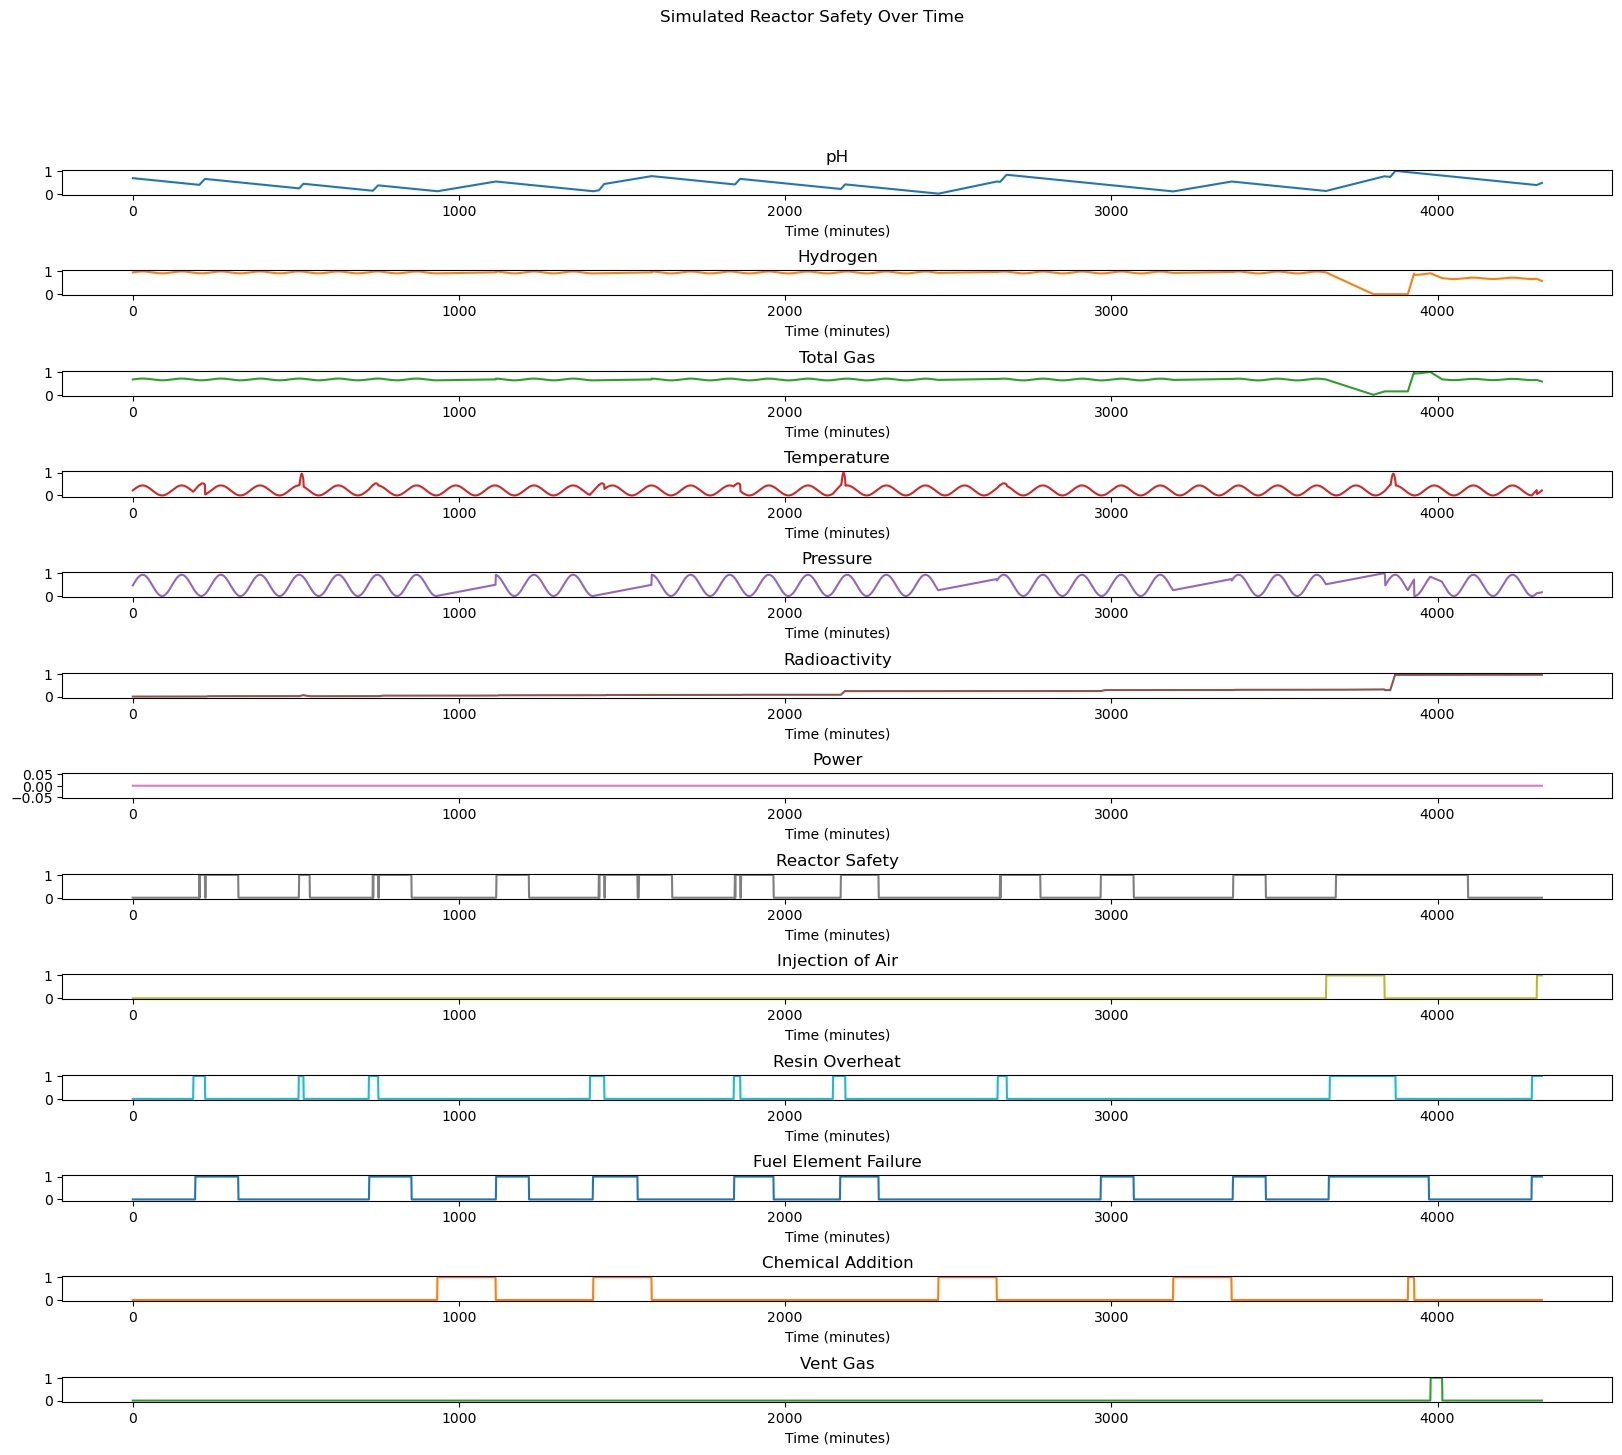

In [36]:
graph_features(np.array(data), safety_features = data.columns)

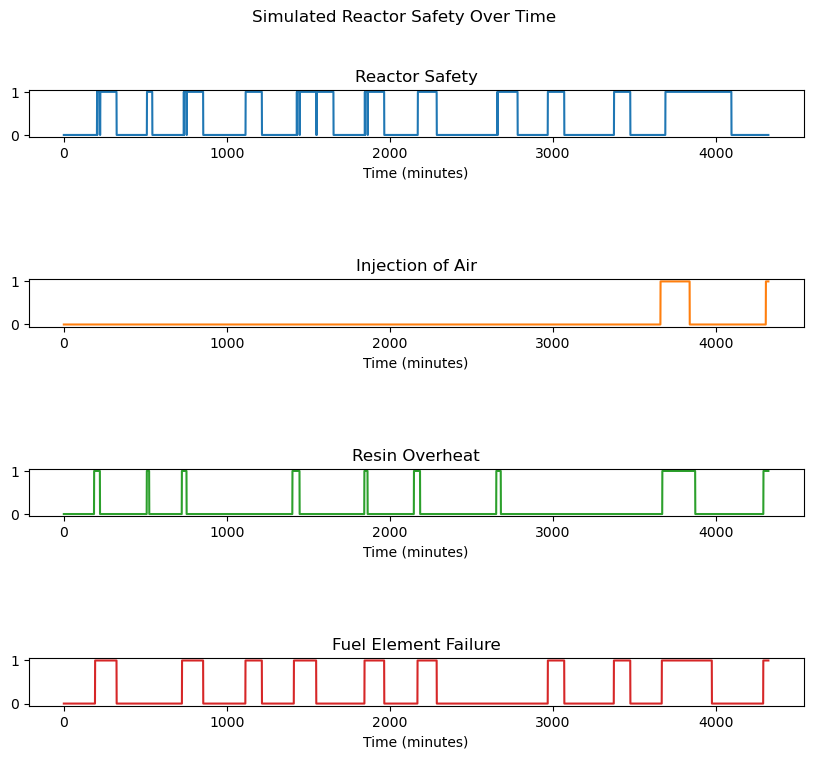

In [42]:
graph_features(np.array(data.iloc[:,7:11]), safety_features = data.columns[7:11])

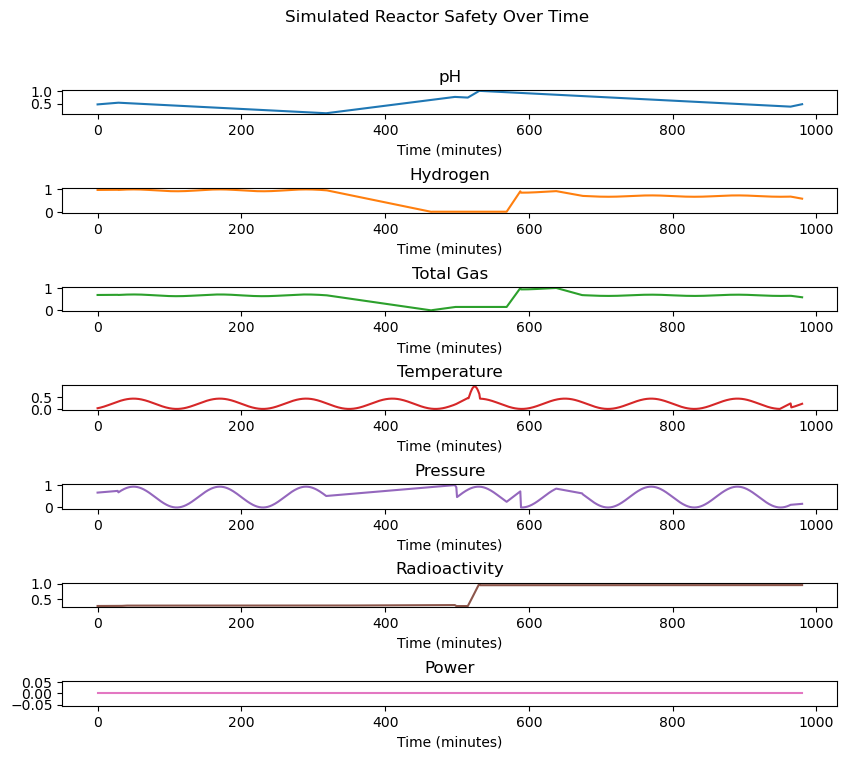

In [29]:
graph_features(y_test[:,199,:], safety_features=data.columns[:7])

In [30]:
y_pred_normalized = my_model.predict(X_test)

2024-12-03 01:06:14.031959: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 01:06:14.034939: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 01:06:14.036833: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

31/31 [==============================] - 6s 160ms/step


In [31]:
y_pred_normalized.shape

(981, 200, 7)

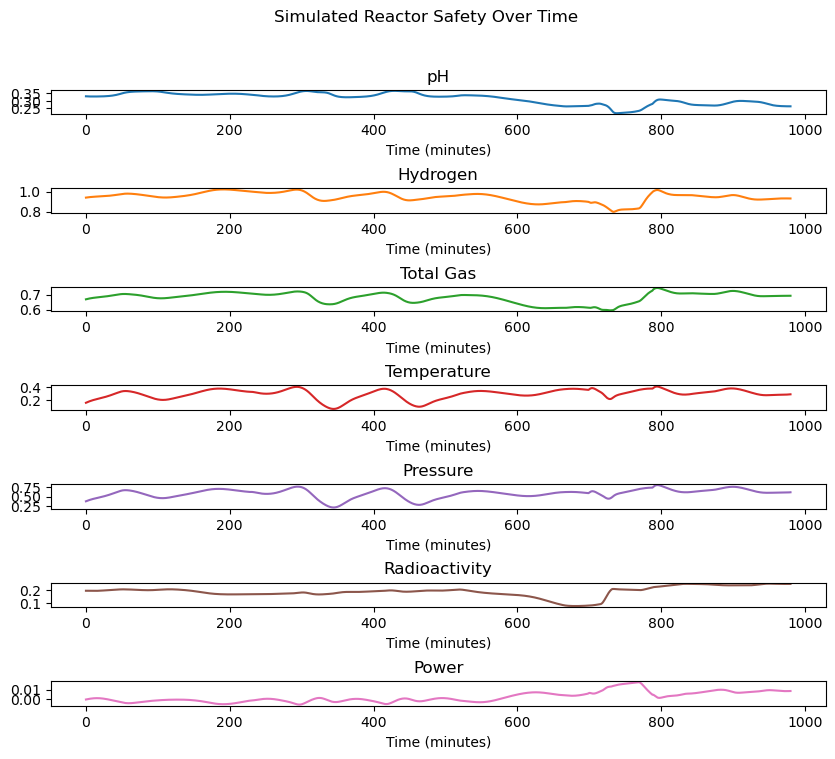

In [32]:
graph_features(y_pred_normalized[:, 199, :], safety_features = data.columns[:7])

In [33]:
print(y_train.shape, y_test.shape)

(2941, 200, 7) (981, 200, 7)


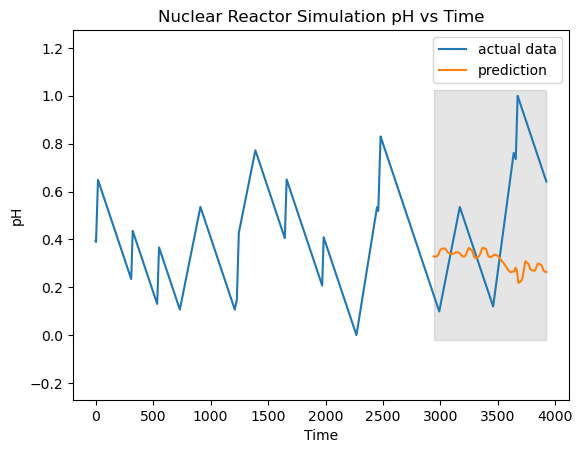

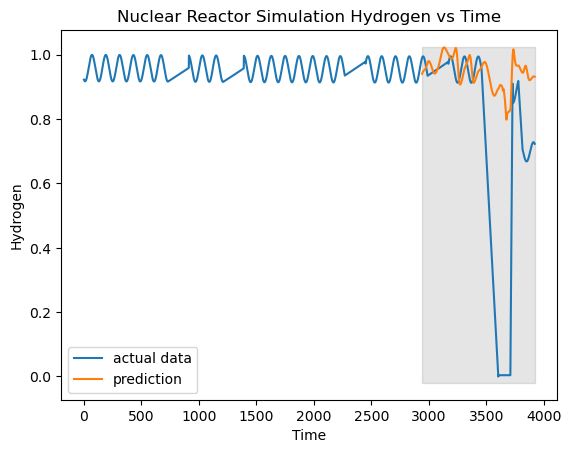

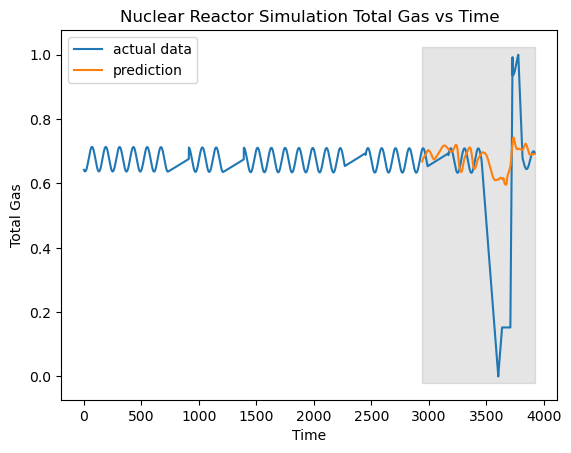

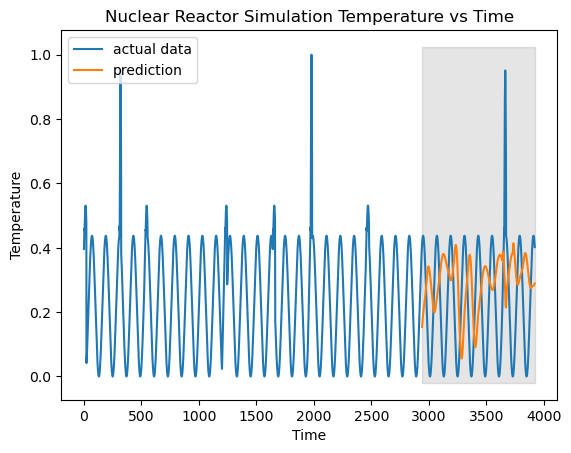

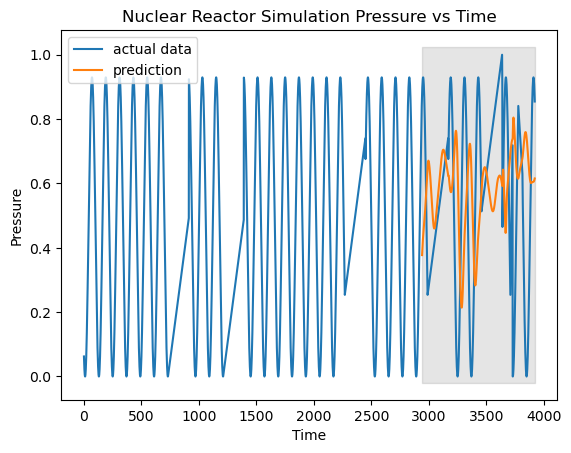

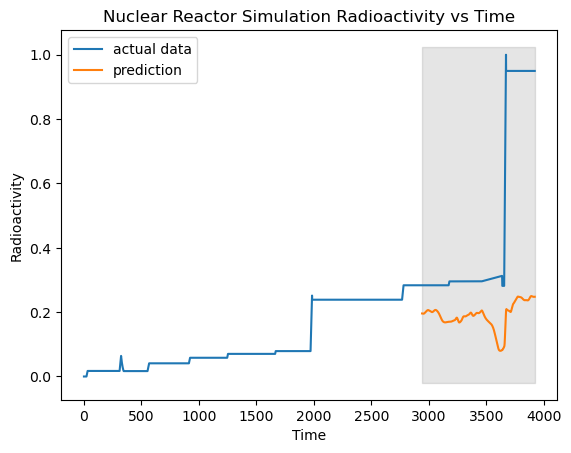

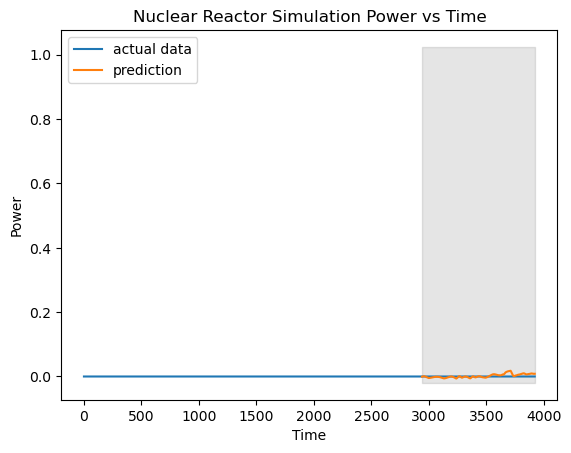

In [34]:
# predicting + transforming normalized data 
back  = y_pred_normalized.shape[0]
y_pred = y_pred_normalized
y_t = y[:, 0, :]
t = range(0,y.shape[0])
# setting bounds for graph
y_min = min(np.min(y_pred), np.min(y_t)) 
y_max = max(np.max(y_pred), np.max(y_t))
plt.ylim(y_min - 0.25, y_max + 0.25)

#parameter_i = 4
for parameter_i in range(7):
    # plot
    plt.plot(t, y_t[:, parameter_i])
    plt.plot(t[-back:], y_pred[:, m_future-1, parameter_i])
    plt.legend(['actual data', 'prediction'])
    plt.fill_between([y_train.shape[0], y_t.shape[0]], y_min, y_max , color = 'k', alpha = 0.1)
    #plt.plot([t[-back,0], t[-back,0]], [y_min, y_max ], 'k-')
    plt.xlabel("Time")
    plt.ylabel(f"{data.columns[parameter_i]}")
    plt.title(f"Nuclear Reactor Simulation {data.columns[parameter_i]} vs Time")
    plt.show()

### Task 2: Safety Classification

In [11]:
# Add padding to y_classification
zeros = np.zeros((y_classification.shape[0], y_classification.shape[1], 1))
y_padded = np.concatenate([y_classification, zeros], axis=2)

In [12]:
y_class_train, y_class_test = train_test_split(y_padded, test_size=0.25, shuffle=False)

In [14]:
from nrsim_lstm import NRSIM_LSTM as lstm
# model setup 

# stacked lstm layers
neurons = [6, 32]
activation = "tanh"

# temporal params
n_past_timesteps = X.shape[1]
n_features = X.shape[2]
n_predicted_timesteps = y.shape[1]

# optimization + metrics
optimizer = "adam"
loss = "categorical_crossentropy"
metrics = ["accuracy", "categorical_crossentropy"]

# convolutional layer
conv_layer = False
nfilters = 64  
conv_act = 'relu' 
pool_size = 2  
dropout=0.2
task = "classification"
n_classes = 6


model2 = lstm(
    neurons,
    activation,
    n_past_timesteps,
    n_features,
    n_predicted_timesteps,
    optimizer,
    loss,
    metrics,
    dropout,
    conv_layer,
    nfilters,
    conv_act,
    pool_size,
    task,
    n_classes
)

2024-12-03 00:21:56.833495: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 00:21:56.835256: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 00:21:56.836919: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [15]:
# fitting model on training data
n_epochs = 20
batch_size = 32


model2.fit(X_train, y_class_train, nEpochs=n_epochs, nBatches=batch_size, val_split=0.2, verb=2, shuf=False)

Epoch 1/20


2024-12-03 00:21:59.503307: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 00:21:59.506425: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 00:21:59.508801: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

74/74 - 41s - loss: 6.0916 - accuracy: 0.1648 - categorical_crossentropy: 6.0916 - val_loss: 3.7746 - val_accuracy: 0.0000e+00 - val_categorical_crossentropy: 3.7746 - 41s/epoch - 559ms/step
Epoch 2/20
74/74 - 37s - loss: 5.1795 - accuracy: 0.0031 - categorical_crossentropy: 5.1795 - val_loss: 2.7865 - val_accuracy: 0.0000e+00 - val_categorical_crossentropy: 2.7865 - 37s/epoch - 504ms/step
Epoch 3/20
74/74 - 49s - loss: 8.5319 - accuracy: 0.0031 - categorical_crossentropy: 8.5319 - val_loss: 7.5387 - val_accuracy: 0.0000e+00 - val_categorical_crossentropy: 7.5387 - 49s/epoch - 668ms/step
Epoch 4/20
74/74 - 52s - loss: 8.2121 - accuracy: 0.0033 - categorical_crossentropy: 8.2121 - val_loss: 7.3770 - val_accuracy: 0.0000e+00 - val_categorical_crossentropy: 7.3770 - 52s/epoch - 696ms/step
Epoch 5/20
74/74 - 40s - loss: 7.6220 - accuracy: 0.0032 - categorical_crossentropy: 7.6220 - val_loss: 6.5432 - val_accuracy: 0.0000e+00 - val_categorical_crossentropy: 6.5432 - 40s/epoch - 538ms/step
E

In [23]:
# model history

out = model2.get_model().history

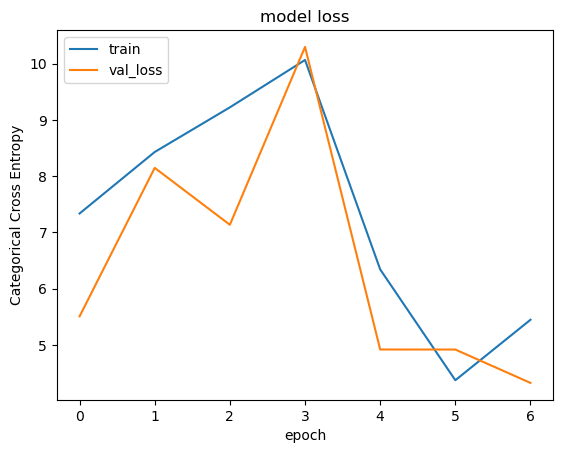

In [25]:
# plotting loss during training
plt.plot(out.history['loss'])
plt.plot(out.history['val_loss'])
plt.title('model loss')
plt.ylabel('Categorical Cross Entropy')
plt.xlabel('epoch')
plt.legend(['train', 'val_loss'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()


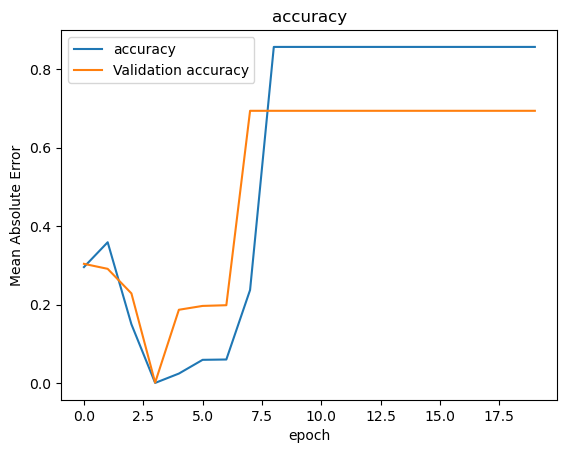

In [26]:
# plot metrics
plt.plot(out.history['accuracy'])
plt.plot(out.history['val_accuracy'])
plt.title('accuracy')
plt.ylabel('Mean Absolute Error')
plt.xlabel('epoch')
plt.legend(['accuracy', 'Validation accuracy'], loc = 'upper left')
plt.savefig('training loss.pdf')
plt.show()

In [27]:
y_pred_classes = model2.predict(X_test)

2024-12-03 00:17:27.157374: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2024-12-03 00:17:27.159836: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2024-12-03 00:17:27.161909: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

31/31 [==============================] - 3s 70ms/step


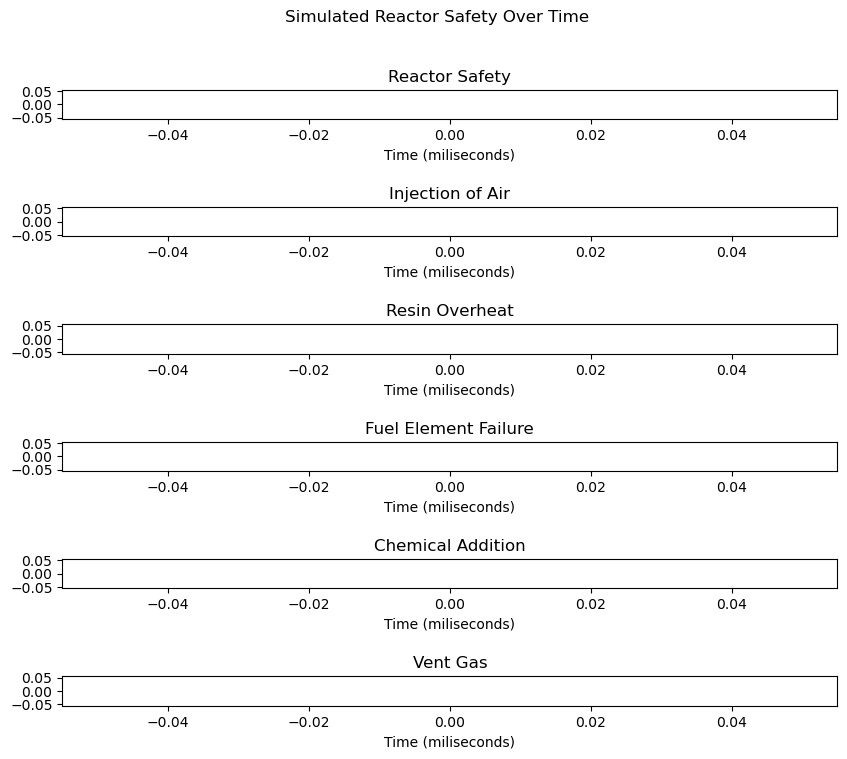

In [30]:
graph_features(y_pred_classes[:, 199, :], safety_features = data.columns[7:])